# GRPO fine-tuning — `translategemma-4b-it` (ES → Valencian)

Loads the SFT checkpoint from HF and runs GRPO with a composite reward:
- **chrF** against the reference (lexical/morphological fidelity)
- **COMET** `wmt22-comet-da` (semantic quality, CPU to avoid OOM)
- **TTR** type-token ratio (penalises vocabulary collapse)
- **copy penalty** — punishes the model for returning the Spanish source untranslated

Published model: `guerreropaula/translategemma4b-grpo2-es-va`

## 1. Dependencies

In [ ]:
%%capture
!pip install -q transformers datasets accelerate peft trl bitsandbytes sacrebleu sentencepiece huggingface_hub unbabel-comet

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
import transformers, peft, trl

print(f"torch        : {torch.__version__}")
print(f"transformers : {transformers.__version__}")
print(f"peft         : {peft.__version__}")
print(f"trl          : {trl.__version__}")
print(f"cuda         : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"gpu          : {torch.cuda.get_device_name(0)}")
    print(f"vram         : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

torch        : 2.10.0+cu128
transformers : 4.57.6
peft         : 0.18.1
trl          : 0.29.0
cuda         : True
gpu          : NVIDIA A100-SXM4-80GB
vram         : 85.1 GB


## 2. Config

In [ ]:
from huggingface_hub import login

HF_TOKEN = ""
login(token=HF_TOKEN)

BASE_MODEL_ID = "google/translategemma-4b-it"
SFT_MODEL_ID  = "guerreropaula/translategemma4b-sft-es-va2"
GRPO_HUB_ID   = "guerreropaula/translategemma4b-grpo2-es-va"
OUTPUT_DIR    = "./translategemma4b_grpo_v2"


SOURCE_LANG_CODE = "es"
TARGET_LANG_CODE = "ca"   # translategemma doesn't distinguish valencian from catalan
SOURCE_COL       = "ES"
TARGET_COL       = "VA"

DEVICE   = "cuda" if torch.cuda.is_available() else "cpu"
USE_BF16 = torch.cuda.is_bf16_supported()

print(f"device: {DEVICE} | bf16: {USE_BF16}")

device: cuda | bf16: True


## 3. Load SFT checkpoint

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel, prepare_model_for_kbit_training

bnb_config = BitsAndBytesConfig(
    load_in_4bit              = True,
    bnb_4bit_use_double_quant = True,
    bnb_4bit_quant_type       = "nf4",
    bnb_4bit_compute_dtype    = torch.bfloat16 if USE_BF16 else torch.float16,
)

# Left-padding for batched generation in GRPO
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID, token=HF_TOKEN)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID,
    quantization_config = bnb_config,
    device_map          = "auto",
    token               = HF_TOKEN,
    torch_dtype         = torch.bfloat16 if USE_BF16 else torch.float16,
    trust_remote_code   = True,
)

# Load SFT adapter on top and keep it trainable
model = PeftModel.from_pretrained(
    base_model,
    SFT_MODEL_ID,
    token        = HF_TOKEN,
    is_trainable = True,
)
model = prepare_model_for_kbit_training(model)
model.print_trainable_parameters()

tokenizer_config.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer.model:   0%|          | 0.00/4.69M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

...

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

adapter_config.json: 0.00B [00:00, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/65.7M [00:00<?, ?B/s]

trainable params: 0 || all params: 4,332,867,952 || trainable%: 0.0000


## 4. Prompt template

In [ ]:
def _make_messages(source_text: str) -> list:
    return [
        {
            "role": "user",
            "content": [
                {
                    "type"             : "text",
                    "source_lang_code" : SOURCE_LANG_CODE,
                    "target_lang_code" : TARGET_LANG_CODE,
                    "text"             : source_text,
                }
            ],
        }
    ]

def make_inference_prompt(source_text: str) -> str:
    """Prompt only (no answer); used for inference and GRPO."""
    return tokenizer.apply_chat_template(
        _make_messages(source_text), tokenize=False, add_generation_prompt=True
    )



print(make_inference_prompt("El ayuntamiento ha aprobado el nuevo presupuesto."))

<bos><start_of_turn>user
You are a professional Spanish (es) to Catalan (ca) translator. Your goal is to accurately convey the meaning and nuances of the original Spanish text while adhering to Catalan grammar, vocabulary, and cultural sensitivities.
Produce only the Catalan translation, without any additional explanations or commentary. Please translate the following Spanish text into Catalan:


El ayuntamiento ha aprobado el nuevo presupuesto.<end_of_turn>
<start_of_turn>model



## 5. GRPO Training Dataset

In [ ]:
from datasets import load_dataset
raw = load_dataset("gplsi/amic_parallel")
print(raw["train"].column_names)
print(raw["train"][0])

README.md: 0.00B [00:00, ?B/s]

data/train/va-es-documents.curated.jsonl:   0%|          | 0.00/404M [00:00<?, ?B/s]

data/train/va-es-paragraph.length.curate(…):   0%|          | 0.00/245M [00:00<?, ?B/s]

data/train/va-es-sentence.length.ner.cur(…):   0%|          | 0.00/91.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/680978 [00:00<?, ? examples/s]

['VA', 'ES', 'source']
{'VA': "Música a la UPV\n\nDel pasdoble 'Agüero' de José Franco, al 'Bolero' de Ravel, gaudeix el divendres 11 del concert de la Banda Simfònica de la UPV a l'Alfons Roig (19.30 h)\n\nL'Auditori Alfons Roig de la Facultat de Belles Arts (edifici 3N, planta baixa) de la Universitat Politècnica de València (UPV) és l'escenari elegit per a la celebració, el pròxim divendres, 11 de març, d'un nou concert de la Banda Simfònica de la UPV.\nAmb accés lliure fins a completar l'aforament del recinte, l'agrupació musical universitària dirigida per Francisco J. Valero interpretarà, a partir de les 19.30 hores, un programa dividit en dues parts.\n\nObres de José Franco, Philip Wilby, Josep Alamà Gil, George Bizet i Maurice Ravel\n\nLa primera començarà a ritme de pasdoble, amb Agüero, de José Franco, peça a la qual seguiran el Concert per a bombardí de Philip Wilby -amb Jorge López Ramos com a solista- i l'obra Nova València, composta per Josep Alamà Gil.\nDesprés del descan

In [ ]:
N_TRAIN = 10_000


def preprocess(examples):
    return {
        "prompt"    : [make_inference_prompt(s) for s in examples["ES"]],
        "reference" : list(examples["VA"]),
        "source_es" : list(examples["ES"]),  # renamed to avoid clash with 'source' column
    }

grpo_dataset = (
    raw["train"]
    .shuffle(seed=42)
    .select(range(N_TRAIN))
    .map(preprocess, batched=True, remove_columns=raw["train"].column_names)
)


print(grpo_dataset)
print("\nprompt sample:")
print(grpo_dataset[0]["prompt"])
print("reference:", grpo_dataset[0]["reference"])

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Dataset({
    features: ['prompt', 'reference', 'source_es'],
    num_rows: 10000
})

prompt sample:
<bos><start_of_turn>user
You are a professional Spanish (es) to Catalan (ca) translator. Your goal is to accurately convey the meaning and nuances of the original Spanish text while adhering to Catalan grammar, vocabulary, and cultural sensitivities.
Produce only the Catalan translation, without any additional explanations or commentary. Please translate the following Spanish text into Catalan:


AVA-Asaja afea a la Comisión Europea que no incluya la almendra en los aranceles a EEUU

La Asociación Valenciana de Agricultores (AVA-ASAJA) reprocha a la Comisión Europea que no incluya la almendra en la lista de productos agrícolas de Estados Unidos a los que ha decidido establecer aranceles, por valor de 3.360 millones de euros, a raíz de la nueva resolución de la Organización Mundial del Comercio (OMC) relacionada con las ayudas concedidas por las dos potencias a sus respectivas industrias

## 6. Load COMET (rank-0 only to avoid GPU OOM)

In [ ]:
import os
import torch.distributed as dist
from comet import download_model, load_from_checkpoint
import logging


LOCAL_RANK     = int(os.environ.get("LOCAL_RANK", 0))
IS_DISTRIBUTED = dist.is_initialized()

comet_model = None
if LOCAL_RANK == 0:
    _path       = download_model("Unbabel/wmt22-comet-da")
    comet_model = load_from_checkpoint(_path).to("cuda")

if IS_DISTRIBUTED:
    dist.barrier()

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

LICENSE: 0.00B [00:00, ?B/s]

.gitattributes: 0.00B [00:00, ?B/s]

README.md: 0.00B [00:00, ?B/s]

hparams.yaml:   0%|          | 0.00/567 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/core/saving.py:197: Found keys that are not in the model state dict but in the checkpoint: ['encoder.model.embeddings.position_ids']


## 7. Reward functions

In [ ]:
import sacrebleu
from typing import List


def chrf_score(hypothesis: str, reference: str) -> float:
    """Sentence-level chrF, normalised to [0, 1].
    chrF is preferred over BLEU here because Valencian has rich morphology
    and chrF rewards partial character n-gram matches.
    """
    if not hypothesis or not reference:
        return 0.0
    return sacrebleu.sentence_chrf(hypothesis, [reference]).score / 100.0


def ttr_score(hypothesis: str) -> float:
    """Type-token ratio — penalizes vocabulary collapse during RL.
    Short sentences (< 5 tokens) are down-weighted to avoid noise.
    """
    if not hypothesis:
        return 0.0
    tokens = hypothesis.lower().split()
    if not tokens:
        return 0.0
    ttr = len(set(tokens)) / len(tokens)
    if len(tokens) < 5:
        ttr *= len(tokens) / 5.0
    return float(ttr)


def copy_penalty(source: str, hypothesis: str) -> float:
    """Penalize copy-through: model outputs the Spanish source instead of translating."""
    if not source or not hypothesis:
        return 0.0

    src = source.strip().lower()
    hyp = hypothesis.strip().lower()

    if src == hyp:
        return -1.0

    sim = sacrebleu.sentence_chrf(hyp, [src]).score / 100.0

    THRESHOLD = 0.7
    if sim > THRESHOLD:
        return -(sim - THRESHOLD) / (1.0 - THRESHOLD)
    return 0.0

def _comet_batch(sources: List[str], hyps: List[str], refs: List[str]) -> List[float]:
    """Run COMET on CPU on rank-0 and broadcast to other ranks."""
    if comet_model is None:
        return [0.5] * len(hyps)
    data   = [{"src": s, "mt": h, "ref": r} for s, h, r in zip(sources, hyps, refs)]
    output = comet_model.predict(data, batch_size=8, gpus=0)
    scores = output.scores if hasattr(output, "scores") else output[0]

    if IS_DISTRIBUTED:
        t = torch.tensor(scores, dtype=torch.float32, device="cuda")
        dist.broadcast(t, src=0)
        scores = t.cpu().tolist()
    return scores



print("reward functions ready")

reward functions ready


## 8. Composite reward

In [ ]:
# Weights
W_CHRF  = 0.5
W_COMET = 0.3
W_TTR   = 0.2
# copy_penalty is additive on top (not weighted), range [−1, 0]

def composite_reward(
    completions: List[str],
    reference:   List[str],
    source_es:      List[str],
    **kwargs,
) -> List[float]:
    """
    r = W_CHRF  * chrF(hyp, ref)
      + W_COMET * COMET(src, hyp, ref)
      + W_TTR   * TTR(hyp)
      + copy_penalty(src, hyp)
    """
    comet_scores = _comet_batch(source_es, completions, reference)

    rewards = []
    for hyp, ref, src, c_s in zip(completions, reference, source_es, comet_scores):
        hyp = hyp.strip() if isinstance(hyp, str) else ""
        r = (
            W_CHRF  * chrf_score(hyp, ref)
          + W_COMET * c_s
          + W_TTR   * ttr_score(hyp)
          + copy_penalty(src, hyp)
        )
        rewards.append(float(r))
    return rewards


# Quick sanity check
_hyps = [
    "L'ajuntament ha aprovat el nou pressupost.",         # good
    "El ayuntamiento ha aprobado el nuevo presupuesto.",  # copy-through
    "El ajuntament ha aprovat el presupuesto.",           # partial
]
_refs = ["L'ajuntament ha aprovat el nou pressupost."] * 3
_srcs = ["El ayuntamiento ha aprobado el nuevo presupuesto."] * 3

for hyp, r in zip(_hyps, composite_reward(_hyps, _refs, _srcs)):
    print(f"r={r:.4f}  |  {hyp}")

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


r=0.9949  |  L'ajuntament ha aprovat el nou pressupost.
r=-0.3955  |  El ayuntamiento ha aprobado el nuevo presupuesto.
r=0.7679  |  El ajuntament ha aprovat el presupuesto.


## 9. GRPO training

In [ ]:
from trl import GRPOConfig, GRPOTrainer
from transformers import TrainerCallback
import matplotlib.pyplot as plt
import gc

OUTPUT_DIR = "./translategemma4b_grpo"

class RewardPlotCallback(TrainerCallback):
    def __init__(self, save_path="grpo_reward_curve.png"):
        self.save_path = save_path
        self.steps   = []
        self.rewards = []
        self.losses  = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and "reward" in logs:
            self.steps.append(state.global_step)
            self.rewards.append(logs["reward"])
            if "loss" in logs:
                self.losses.append(logs["loss"])

            plt.figure(figsize=(10, 4))
            plt.plot(self.steps, self.rewards, lw=1.5, color="#1D9E75")
            plt.axhline(0, color="gray", lw=0.8, ls="--", alpha=0.4)
            plt.xlabel("step")
            plt.ylabel("mean reward")
            plt.title("GRPO reward")
            plt.grid(alpha=0.25)
            plt.tight_layout()
            plt.savefig(self.save_path, dpi=150, bbox_inches="tight")
            plt.close()

grpo_config = GRPOConfig(
    max_completion_length       = 128,
    num_generations             = 4,
    per_device_train_batch_size = 1,
    gradient_accumulation_steps = 16,
    max_steps                   = 200,
    learning_rate               = 5e-6,
    warmup_steps                = 20,
    lr_scheduler_type           = "cosine",
    optim                       = "paged_adamw_8bit",
    weight_decay                = 0.01,
    beta                        = 0.04,
    epsilon                     = 0.2,
    bf16                        = USE_BF16,
    fp16                        = not USE_BF16,
    gradient_checkpointing      = True,
    output_dir                  = OUTPUT_DIR,
    logging_steps               = 10,
    save_steps                  = 10,
    report_to                   = "none",
    seed                        = 42,
)

trainer = GRPOTrainer(
    model            = model,
    processing_class = tokenizer,
    reward_funcs     = composite_reward,
    args             = grpo_config,
    train_dataset    = grpo_dataset,
    callbacks        = [RewardPlotCallback("grpo_reward_curve.png")],
)

print(f"trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6:.1f}M")

trainable params: 32.8M


In [ ]:
torch.cuda.empty_cache()
gc.collect()
print(f"vram before training: {torch.cuda.memory_reserved()/1e9:.2f} GB")


vram before training: 7.37 GB


In [ ]:
test_hyps = [
    "L'ajuntament ha aprovat el nou pressupost.",                          # perfect
    "El ayuntamiento ha aprobado el nuevo presupuesto.",                   # exact copy
    "El ajuntament ha aprovat el presupuesto.",                            # mixed ES/CA
    "L'ajuntament ha aprovat un nou pressupost municipal.",                # good but not exact
    "The council has approved the new budget.",                            # english (wrong lang)
    "L'ajuntament ha aprovat el nou pressupost el nou pressupost el nou.", # repetitive (low TTR)
    "Sí.",                                                                 # too short
    "El ayuntamiento aprobó el presupuesto nuevo hoy en la reunión.",      # copy variant
    "L'ajuntament va aprovar el nou pressupost ahir.",                     # good CA, diff tense
    "Ha aprovat pressupost ajuntament nou el.",                            # scrambled words
]
test_refs = ["L'ajuntament ha aprovat el nou pressupost."] * len(test_hyps)
test_srcs = ["El ayuntamiento ha aprobado el nuevo presupuesto."] * len(test_hyps)

rewards = composite_reward(test_hyps, test_refs, test_srcs)

print(f"{'r':>8}  {'label':<15}  hypothesis")
print("-" * 80)
labels = [
    "perfect",
    "exact copy",
    "mixed ES/CA",
    "good not exact",
    "wrong lang",
    "repetitive",
    "too short",
    "copy variant",
    "good diff tense",
    "scrambled",
]
for hyp, label, r in zip(test_hyps, labels, rewards):
    print(f"{r:>8.4f}  {label:<15}  {hyp[:60]}")

print("\n--- sanity checks ---")
assert rewards[0] > rewards[1], "perfect > exact copy"
assert rewards[1] < 0,          "exact copy should be negative"
assert rewards[0] > rewards[2], "perfect > mixed"
assert rewards[0] > rewards[5], "perfect > repetitive"
assert rewards[0] > rewards[9], "perfect > scrambled"
assert rewards[3] > rewards[1], "good not exact > copy"
assert rewards[8] > rewards[1], "good diff tense > copy"
print("all checks passed — safe to train")

[comet] 'score'
       r  label            hypothesis
--------------------------------------------------------------------------------
  0.8500  perfect          L'ajuntament ha aprovat el nou pressupost.
 -0.5146  exact copy       El ayuntamiento ha aprobado el nuevo presupuesto.
  0.6361  mixed ES/CA      El ajuntament ha aprovat el presupuesto.
  0.7524  good not exact   L'ajuntament ha aprovat un nou pressupost municipal.
  0.4004  wrong lang       The council has approved the new budget.
  0.7143  repetitive       L'ajuntament ha aprovat el nou pressupost el nou pressupost 
  0.1955  too short        Sí.
  0.4592  copy variant     El ayuntamiento aprobó el presupuesto nuevo hoy en la reunió
  0.7271  good diff tense  L'ajuntament va aprovar el nou pressupost ahir.
  0.6707  scrambled        Ha aprovat pressupost ajuntament nou el.

--- sanity checks ---
all checks passed — safe to train


In [ ]:
from peft import PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch



model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    torch_dtype=torch.bfloat16 if USE_BF16 else torch.float16,
    device_map="auto",
)
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

model = PeftModel.from_pretrained(
    model,
    HF_ADAPTER,
    is_trainable=True,
)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
grpo_config = GRPOConfig(
    max_completion_length       = 128,
    num_generations             = 4,
    per_device_train_batch_size = 1,
    gradient_accumulation_steps = 16,
    max_steps                   = 200,
    learning_rate               = 5e-6,
    warmup_steps                = 20,
    lr_scheduler_type           = "cosine",
    optim                       = "paged_adamw_8bit",
    weight_decay                = 0.01,
    beta                        = 0.04,
    epsilon                     = 0.2,
    bf16                        = USE_BF16,
    fp16                        = not USE_BF16,
    gradient_checkpointing      = True,
    output_dir                  = OUTPUT_DIR,
    logging_steps               = 10,
    save_steps                  = 10,
    report_to                   = "none",
    seed                        = 3407,
)

trainer = GRPOTrainer(
    model            = model,
    processing_class = tokenizer,
    reward_funcs     = composite_reward,
    args             = grpo_config,
    train_dataset    = grpo_dataset,
    callbacks        = [RewardPlotCallback("grpo_reward_curve.png")],
)

stats = trainer.train()

The model is already on multiple devices. Skipping the move to device specified in `args`.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 1, 'bos_token_id': 2, 'pad_token_id': 0}.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
Could not estimate the number of tokens of the input, floating-point operations will not be computed


Step,Training Loss
10,0.020000
20,-0.017400
30,-0.024700
40,0.002000
50,-0.002000
60,0.012300
70,0.026600
80,0.005300
90,-0.017200
100,-0.029300


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


In [ ]:
import json, os

ckpt_dir = "./translategemma4b_grpo"
checkpoints = sorted([
    d for d in os.listdir(ckpt_dir)
    if d.startswith("checkpoint-")
], key=lambda x: int(x.split("-")[1]))

for ckpt in checkpoints:
    state_path = os.path.join(ckpt_dir, ckpt, "trainer_state.json")
    if os.path.exists(state_path):
        with open(state_path) as f:
            state = json.load(f)
        last_log = state["log_history"][-1]
        step = last_log.get("step", "?")
        reward = last_log.get("reward", "N/A")
        print(f"{ckpt}  →  step {step}  reward {reward}")

checkpoint-10  →  step 10  reward 0.7086213231086731
checkpoint-20  →  step 20  reward 0.7148244380950928
checkpoint-30  →  step 30  reward 0.7145927250385284
checkpoint-40  →  step 40  reward 0.6509764492511749
checkpoint-50  →  step 50  reward 0.7453538775444031
checkpoint-60  →  step 60  reward 0.7135930538177491
checkpoint-70  →  step 70  reward 0.7269721746444702
checkpoint-80  →  step 80  reward 0.7815159559249878
checkpoint-90  →  step 90  reward 0.6881891667842865
checkpoint-100  →  step 100  reward 0.8316982567310334
checkpoint-110  →  step 110  reward 0.8042254328727723
checkpoint-120  →  step 120  reward 0.7020611077547073
checkpoint-130  →  step 130  reward 0.7683198571205139
checkpoint-140  →  step 140  reward 0.7707165002822876
checkpoint-150  →  step 150  reward 0.7781365036964416
checkpoint-160  →  step 160  reward 0.7338260114192963
checkpoint-170  →  step 170  reward 0.7287277936935425
checkpoint-180  →  step 180  reward 0.7671338379383087
checkpoint-190  →  step 190 

## 10. Save and Push to HuggingFace Hub


In [ ]:
from peft import PeftModel
import torch

BEST_CKPT = "./translategemma4b_grpo/checkpoint-100"
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    torch_dtype=torch.bfloat16 if USE_BF16 else torch.float16,
    device_map="cuda",
)


peft_model = PeftModel.from_pretrained(base_model, BEST_CKPT)


merged_model = peft_model.merge_and_unload()

merged_model.push_to_hub(
    "guerreropaula/translategemma4b-grpo2-es-va-best-merged",
    safe_serialization=True,
    max_shard_size="2GB",
)
tokenizer.push_to_hub("guerreropaula/translategemma4b-grpo2-es-va-best-merged")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...0002-of-00005.safetensors:   0%|          |  607kB / 1.99GB            

  ...0005-of-00005.safetensors:   0%|          | 14.3kB / 1.80GB            

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...pqt30q5b2/tokenizer.model: 100%|##########| 4.69MB / 4.69MB            

  ...mpqt30q5b2/tokenizer.json: 100%|##########| 33.4MB / 33.4MB            

CommitInfo(commit_url='https://huggingface.co/guerreropaula/translategemma4b-grpo2-es-va-best-merged/commit/a00f55bbb6a9752ec1bef8476f8f961e8be4f982', commit_message='Upload tokenizer', commit_description='', oid='a00f55bbb6a9752ec1bef8476f8f961e8be4f982', pr_url=None, repo_url=RepoUrl('https://huggingface.co/guerreropaula/translategemma4b-grpo2-es-va-best-merged', endpoint='https://huggingface.co', repo_type='model', repo_id='guerreropaula/translategemma4b-grpo2-es-va-best-merged'), pr_revision=None, pr_num=None)

## 11. Reward curve

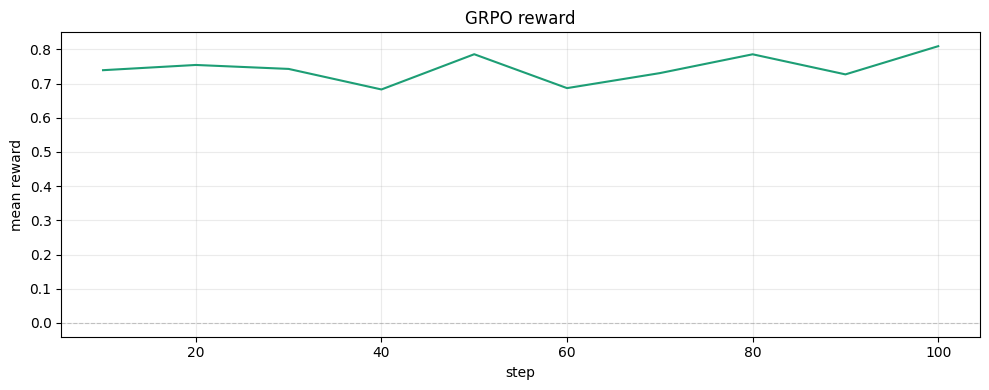

In [ ]:
# STEP 100
import matplotlib.pyplot as plt

steps, rwds = [], []
for entry in trainer.state.log_history:
    if "reward" in entry:
        steps.append(entry.get("step", len(steps)))
        rwds.append(entry["reward"])

if steps:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(steps, rwds, lw=1.5, color="#1D9E75")
    ax.axhline(0, color="gray", lw=0.8, ls="--", alpha=0.4)
    ax.set(xlabel="step", ylabel="mean reward", title="GRPO reward")
    ax.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig("grpo_reward.png", dpi=150)
    plt.show()
else:
    print("no reward entries in log")

## 12. Quick Evaluation Check

In [ ]:
from datasets import load_dataset as ld
import sacrebleu

N_QUICK = 100
test_ds = ld("gplsi/ES-VA_translation_test", split="test").select(range(N_QUICK))
gold_es = [ex["es"] for ex in test_ds]
gold_va = [ex["va"] for ex in test_ds]

merged_model.eval()
tokenizer.padding_side = "left"
hyps = []
for src in gold_es:
    prompt = make_inference_prompt(src)
    enc    = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        out = merged_model.generate(**enc, max_new_tokens=128, do_sample=False,
                                    pad_token_id=tokenizer.pad_token_id)
    text = tokenizer.decode(out[0], skip_special_tokens=True)
    if "model" in text: text = text.split("model")[-1].strip()
    hyps.append(text)

chrf = sacrebleu.corpus_chrf(hyps, [gold_va]).score
bleu = sacrebleu.corpus_bleu(hyps, [gold_va]).score
print(f"Quick eval ({N_QUICK} sents) — chrF: {chrf:.2f} | BLEU: {bleu:.2f}")